# Amazon Video Games — XGBoost Sales Rank Prediction

目標：整合所有特徵，訓練 XGBoost 模型預測商品銷售排名（log_rank）。

輸入特徵：
- 評論統計特徵（avg_rating、total_reviews、verified_ratio 等）
- 影響力評論者特徵（inf_review_ratio、inf_review_count）
- BERTopic 主題特徵（各主題評論比例）
- 商品基本特徵（price）

預測目標：log_rank

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path().resolve().parent
PROCESSED  = ROOT / 'data' / 'processed'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('套件載入完成')

套件載入完成


## 1. 整合所有特徵

In [2]:
# 讀取資料
reviews  = pd.read_csv(PROCESSED / 'reviews_clean.csv', parse_dates=['date'])
meta     = pd.read_csv(PROCESSED / 'meta_clean.csv')
topic_df = pd.read_csv(PROCESSED / 'product_topic_features.csv')

reviews = reviews[reviews['helpful_vote'] >= 0]

print(f'評論數：{len(reviews):,}')
print(f'商品數（meta）：{len(meta):,}')
print(f'商品數（topic features）：{len(topic_df):,}')

評論數：3,670,126
商品數（meta）：74,321
商品數（topic features）：17,024


In [3]:
# ── 特徵 1：評論統計特徵 ──────────────────────────────────────────────────

# 影響力評論者標記
reviewer_stats = reviews.groupby('user_id').agg(
    max_helpful_vote = ('helpful_vote', 'max')
).reset_index()
reviewer_stats['is_influential'] = reviewer_stats['max_helpful_vote'] >= 10
reviews = reviews.merge(reviewer_stats[['user_id', 'is_influential']], on='user_id', how='left')

# 商品層級聚合
product_features = reviews.groupby('parent_asin').agg(
    total_reviews      = ('rating', 'count'),
    avg_rating         = ('rating', 'mean'),
    rating_std         = ('rating', 'std'),
    avg_helpful_vote   = ('helpful_vote', 'mean'),
    avg_text_length    = ('text_length', 'mean'),
    verified_ratio     = ('verified_purchase', 'mean'),
    inf_review_count   = ('is_influential', 'sum'),
    inf_review_ratio   = ('is_influential', 'mean'),
    rating_1_ratio     = ('rating', lambda x: (x == 1).mean()),
    rating_5_ratio     = ('rating', lambda x: (x == 5).mean()),
).reset_index()

product_features['rating_std'] = product_features['rating_std'].fillna(0)

print(f'評論統計特徵：{product_features.shape}')

評論統計特徵：(74280, 11)


In [4]:
# ── 特徵 2：商品基本特徵 ──────────────────────────────────────────────────

meta_features = meta[['parent_asin', 'log_rank', 'rank', 'price']].copy()

# ── 合併所有特徵 ──────────────────────────────────────────────────────────

df = product_features.merge(meta_features, on='parent_asin', how='inner')
df = df.merge(
    topic_df.drop(columns=['log_rank', 'rank'], errors='ignore'),
    on='parent_asin',
    how='left'
)

print(f'合併後：{df.shape[0]} 個商品 x {df.shape[1]} 個欄位')
print(f'缺失值比例：\n{(df.isnull().mean() * 100).sort_values(ascending=False).head(10).round(1).to_string()}')

合併後：74280 個商品 x 63 個欄位
缺失值比例：
topic_17_ratio    77.1
topic_33_ratio    77.1
topic_20_ratio    77.1
topic_21_ratio    77.1
topic_22_ratio    77.1
topic_23_ratio    77.1
topic_24_ratio    77.1
topic_25_ratio    77.1
topic_26_ratio    77.1
topic_27_ratio    77.1


## 2. 準備訓練資料

In [5]:
# 移除不需要的欄位
drop_cols = ['parent_asin', 'rank']
df_model  = df.drop(columns=drop_cols)

# 填補缺失值
df_model['price'] = df_model['price'].fillna(df_model['price'].median())
topic_cols = [c for c in df_model.columns if c.startswith('topic_')]
df_model[topic_cols] = df_model[topic_cols].fillna(0)

# 目標變數
y = df_model.pop('log_rank')
X = df_model

print(f'特徵數：{X.shape[1]}')
print(f'樣本數：{X.shape[0]}')
print(f'目標變數（log_rank）：mean={y.mean():.2f}, std={y.std():.2f}')

# 切分訓練集和測試集（80/20）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'訓練集：{len(X_train):,}，測試集：{len(X_test):,}')

特徵數：60
樣本數：74280
目標變數（log_rank）：mean=11.00, std=1.06
訓練集：59,424，測試集：14,856


## 3. 訓練 XGBoost 模型

In [6]:
model = xgb.XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print('訓練完成')

[0]	validation_0-rmse:1.03286
[100]	validation_0-rmse:0.80513
[200]	validation_0-rmse:0.79829
[300]	validation_0-rmse:0.79650
[400]	validation_0-rmse:0.79559
[499]	validation_0-rmse:0.79555
訓練完成


## 4. 評估模型表現

模型評估結果
訓練集 R²  : 0.5373
測試集 R²  : 0.4231
訓練集 RMSE: 0.7213
測試集 RMSE: 0.7955



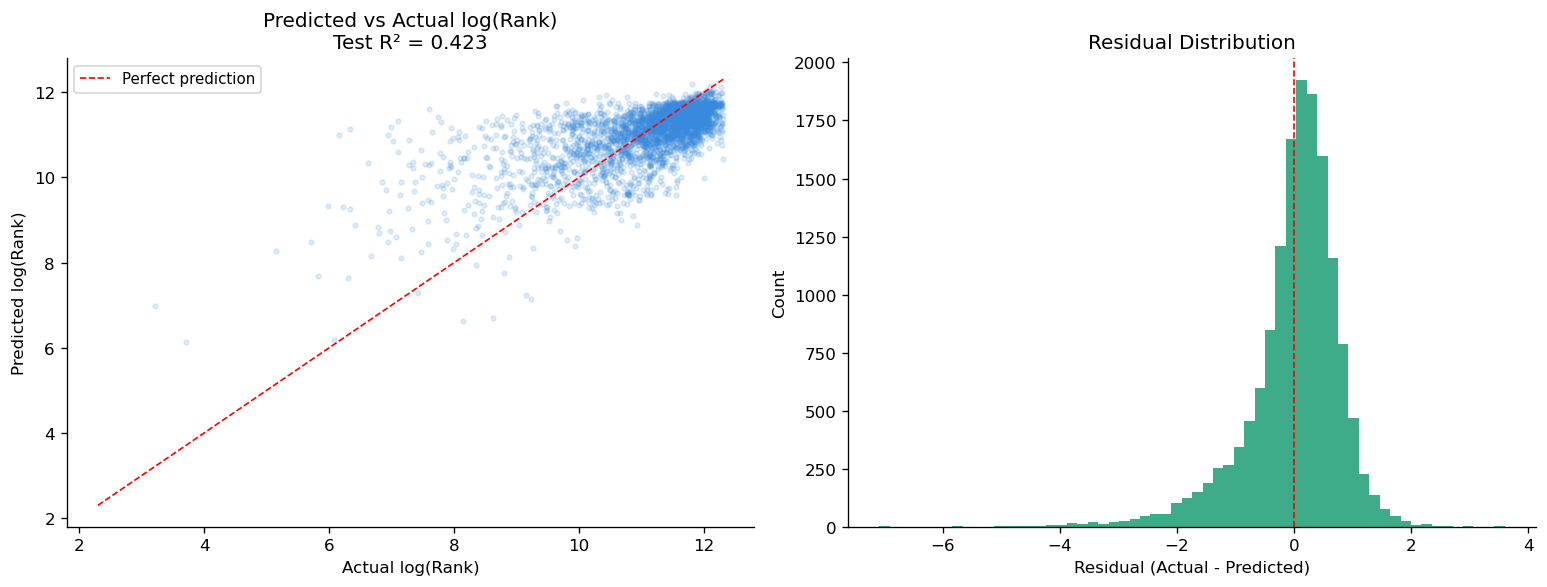

✅ 儲存：13_model_performance.png


In [7]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('=' * 45)
print('模型評估結果')
print('=' * 45)
print(f'訓練集 R²  : {r2_train:.4f}')
print(f'測試集 R²  : {r2_test:.4f}')
print(f'訓練集 RMSE: {rmse_train:.4f}')
print(f'測試集 RMSE: {rmse_test:.4f}')
print()

# 預測值 vs 實際值散點圖
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 散點圖
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(
    y_test.iloc[sample_idx],
    y_pred_test[sample_idx],
    alpha=0.15, s=8, color='#378ADD'
)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_title(f'Predicted vs Actual log(Rank)\nTest R² = {r2_test:.3f}', fontsize=12)
axes[0].set_xlabel('Actual log(Rank)')
axes[0].set_ylabel('Predicted log(Rank)')
axes[0].legend(fontsize=9)

# 殘差分佈
residuals = y_test.values - y_pred_test
axes[1].hist(residuals, bins=60, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution', fontsize=12)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '13_model_performance.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：13_model_performance.png')

## 5. 特徵重要性分析

前 25 個最重要特徵：
total_reviews       0.141593
price               0.048311
topic_34_ratio      0.039870
verified_ratio      0.039828
topic_39_ratio      0.037217
topic_17_ratio      0.025660
inf_review_count    0.025044
topic_5_ratio       0.022838
topic_31_ratio      0.021594
rating_5_ratio      0.021328
topic_12_ratio      0.021016
topic_1_ratio       0.020793
topic_2_ratio       0.019359
inf_review_ratio    0.019062
topic_6_ratio       0.018100
topic_8_ratio       0.017918
topic_19_ratio      0.017432
topic_43_ratio      0.017234
rating_std          0.016753
topic_28_ratio      0.016367
topic_3_ratio       0.015752
avg_helpful_vote    0.015537
topic_11_ratio      0.015229
topic_10_ratio      0.014955
topic_15_ratio      0.013571


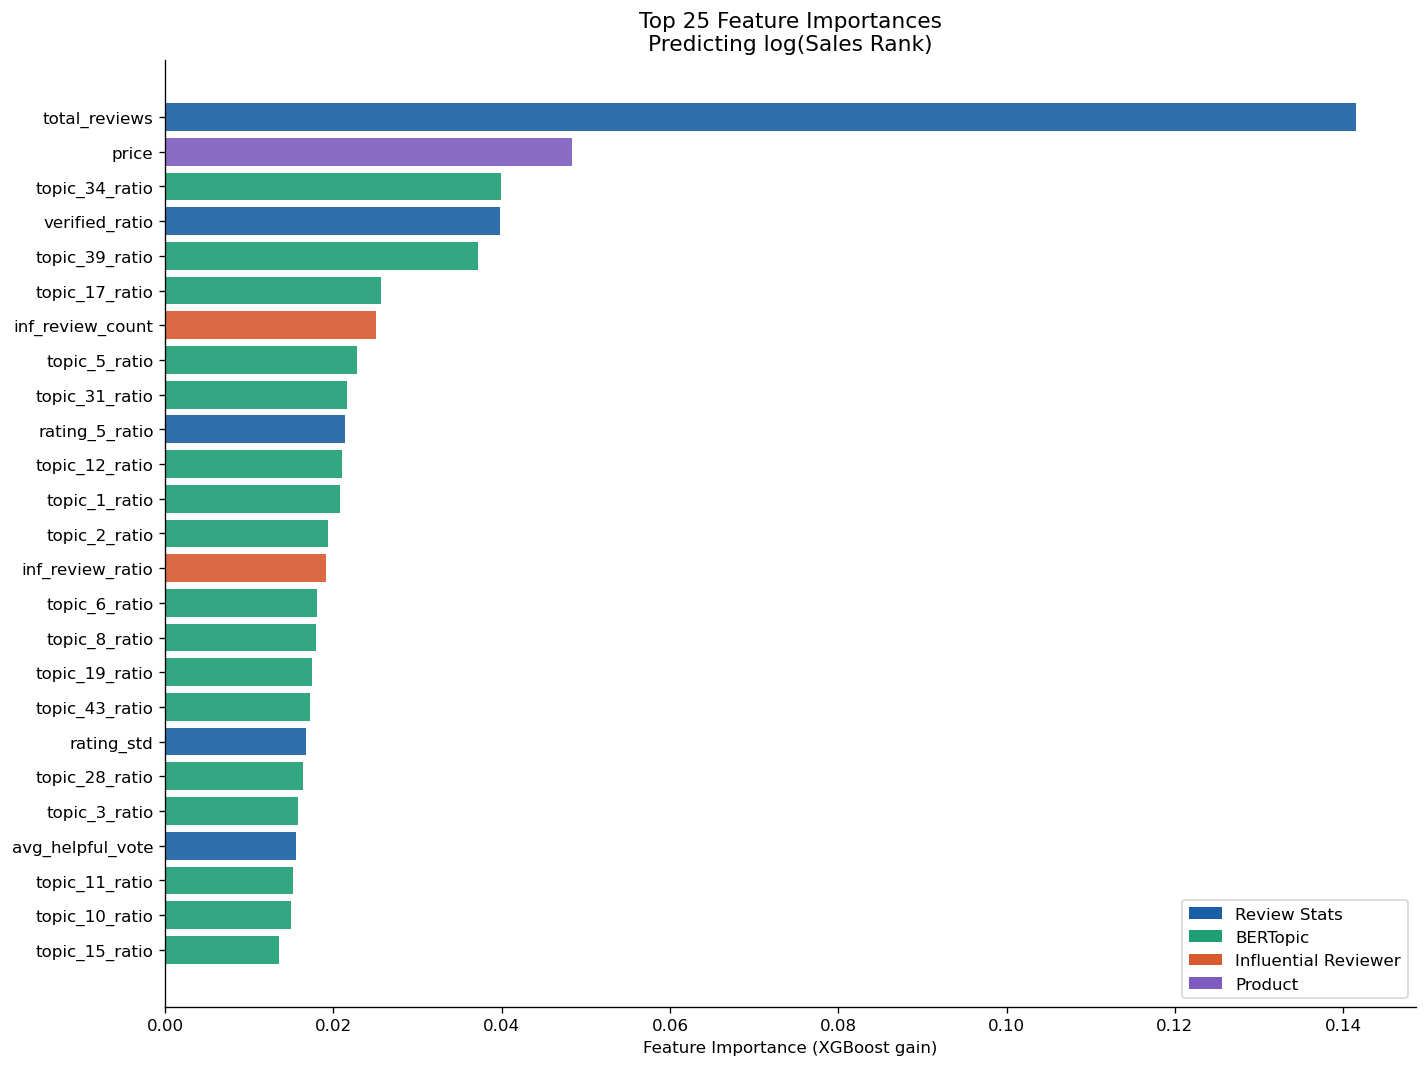

✅ 儲存：14_feature_importance.png


In [8]:
# 取前 25 個最重要的特徵
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top25 = importance.head(25)

print('前 25 個最重要特徵：')
print(top25.to_string())

# 分類特徵類型
def classify_feature(name):
    if name.startswith('topic_'):
        return 'BERTopic'
    elif name in ['inf_review_ratio', 'inf_review_count']:
        return 'Influential Reviewer'
    elif name == 'price':
        return 'Product'
    else:
        return 'Review Stats'

colors_map = {
    'Review Stats'        : '#185FA5',
    'BERTopic'            : '#1D9E75',
    'Influential Reviewer': '#D85A30',
    'Product'             : '#7C5CBF',
}

bar_colors = [colors_map[classify_feature(f)] for f in top25.index]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(len(top25)), top25.values,
               color=bar_colors, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=10)
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Top 25 Feature Importances\nPredicting log(Sales Rank)', fontsize=13)
ax.invert_yaxis()

# 圖例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_feature_importance.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：14_feature_importance.png')

## 6. 各類特徵的貢獻比例

各類特徵的貢獻比例：
BERTopic                63.799999
Review Stats            26.900000
Product                  4.800000
Influential Reviewer     4.400000


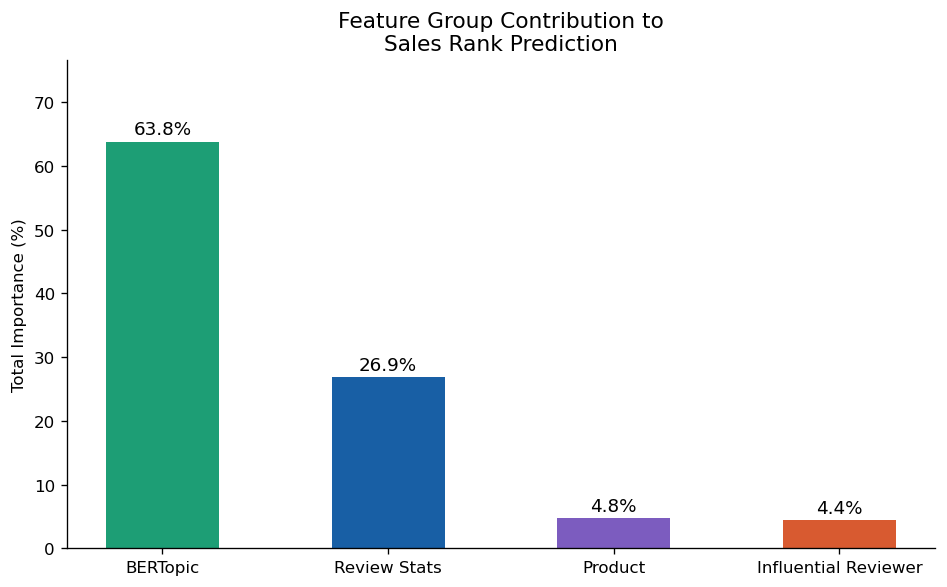

✅ 儲存：15_feature_group_importance.png


In [9]:
# 計算各類特徵的總重要性
all_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

group_importance = all_importance.groupby(
    all_importance.index.map(classify_feature)
).sum().sort_values(ascending=False)

group_pct = (group_importance / group_importance.sum() * 100).round(1)

print('各類特徵的貢獻比例：')
print(group_pct.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_group = [colors_map[k] for k in group_pct.index]
bars = ax.bar(group_pct.index, group_pct.values,
              color=bar_colors_group, edgecolor='none', width=0.5)

for bar, val in zip(bars, group_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Feature Group Contribution to\nSales Rank Prediction', fontsize=13)
ax.set_ylabel('Total Importance (%)')
ax.set_ylim(0, group_pct.max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '15_feature_group_importance.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：15_feature_group_importance.png')

## 7. 模型摘要

In [10]:
print('=' * 55)
print('XGBoost 模型摘要')
print('=' * 55)
print(f'樣本數           : {len(X):,} 個商品')
print(f'特徵數           : {X.shape[1]} 個')
print(f'  - 評論統計特徵 : {sum(1 for c in X.columns if classify_feature(c)=="Review Stats")} 個')
print(f'  - BERTopic 特徵: {sum(1 for c in X.columns if classify_feature(c)=="BERTopic")} 個')
print(f'  - 影響力評論者 : {sum(1 for c in X.columns if classify_feature(c)=="Influential Reviewer")} 個')
print(f'  - 商品特徵     : {sum(1 for c in X.columns if classify_feature(c)=="Product")} 個')
print()
print(f'測試集 R²        : {r2_test:.4f}')
print(f'測試集 RMSE      : {rmse_test:.4f} (log_rank 單位)')
print()
print(f'最重要的前 5 個特徵：')
for i, (feat, val) in enumerate(importance.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

XGBoost 模型摘要
樣本數           : 74,280 個商品
特徵數           : 60 個
  - 評論統計特徵 : 8 個
  - BERTopic 特徵: 49 個
  - 影響力評論者 : 2 個
  - 商品特徵     : 1 個

測試集 R²        : 0.4231
測試集 RMSE      : 0.7955 (log_rank 單位)

最重要的前 5 個特徵：
  1. total_reviews: 0.1416
  2. price: 0.0483
  3. topic_34_ratio: 0.0399
  4. verified_ratio: 0.0398
  5. topic_39_ratio: 0.0372
